## 3. F2052-15 Appendix X3 Extrapolation
Using **measured** B₀_L and |∇B|_L from the field map (no hardcoding).

**What |∇B|_C means (Eq. X3.9):**
|∇B|_C is the **maximum spatial gradient this device could safely tolerate** in a scanner
operating at field strength B₀_C, assuming FR = 1 (α = 45°) as the conservative limit.

It is a **material tolerance ceiling** derived from your measurement, not a measured value.

**The correct comparison is:**
- |∇B|_C **>** scanner max gradient → ✅ SAFE — the device tolerates more than any clinical scanner produces
- |∇B|_C **<** scanner max gradient → ❌ UNSAFE — a clinical scanner could push the device past FR = 1

Per §X3.1.3: typical max |∇B| in patient-accessible areas is < 19 T/m at 1.5T and < 17 T/m at 3T.


## 1. Load Pre-Computed Outputs
Loads `summary_df` and `mean_results` saved by the upstream notebooks.
No re-execution — no plots, no processing overhead.

> **To refresh:** re-run `ClinicalBfieldAnalysis.ipynb` and/or `Translational_F2052.ipynb`, 
> then re-run this cell to pick up the updated `.pkl` files.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import warnings
warnings.filterwarnings('ignore')

# ── Load pre-computed outputs from upstream notebooks ─────────
# Re-run ClinicalBfieldAnalysis.ipynb and Translational_F2052.ipynb
# whenever the underlying data changes, then reload here.

CLINICAL_PKL     = 'MappingBField/outputs/clinical_summary.pkl'
MEAN_RESULTS_PKL = 'TranslationalExperiment/outputs/mean_results.pkl'

with open(CLINICAL_PKL, 'rb') as f:
    summary_df = pickle.load(f)

with open(MEAN_RESULTS_PKL, 'rb') as f:
    mean_results = pickle.load(f)

print(f'✅ summary_df    : {len(summary_df)} rows, '
      f'coords: {summary_df["coord"].unique().tolist()}')
print(f'✅ mean_results  : {list(mean_results.keys())}')
print(f'   summary_df columns: {list(summary_df.columns)}')


✅ summary_df    : 28 rows, coords: ['00', 'A3', 'A6', 'D3', 'G3', 'G6']
✅ mean_results  : ['Ti_Coil', 'Bipolar_Lead', 'Ti_Rod', 'SS_316L']
   summary_df columns: ['coord', 'pass', 'sub_run', 'max_B_T', 'pos_maxB_m', 'max_gradB_Tm', 'pos_maxG_m', 'max_BgradB_T2m', 'pos_maxBg_m', 'behaviour']


## 2. Identify Test Location from Field Map (F2052-15 §8.1)

Per §8.1, the test location must be:
- On the bore axis
- Where |∇B| is **within 20% of its maximum value** on the axis

We use the G6 coordinate (bore axis representative) and find the position where  
|∇B| ≥ 0.80 × max|∇B| — i.e. the entry point of the 20%-window closest to the bore entrance.

In [2]:
# ── Configuration ─────────────────────────────────────────────────
# Coordinate used as test location (bore axis representative)
TEST_COORD = 'G6'

# Clinical target field strengths for extrapolation
CLINICAL_B0 = {
    '1.5T': 1.5,
    '3.0T': 3.0,
}

# F2052-15 §X3.1.3 — typical max |∇B| in patient-accessible areas
SCANNER_GRAD_LIMITS = {
    '1.5T': 19.0,   # T/m
    '3.0T': 17.0,   # T/m
}

# Conservative acceptance threshold (§5.2)
ALPHA_C_DEG = 45.0
TAN_ALPHA_C = np.tan(np.radians(ALPHA_C_DEG))   # = 1.0

# ── Filter summary_df to test coordinate, best sub-run (B) ───────
# Use Sub-run B (cleaner gradient per upstream notebook note)
# and Forward pass (entering bore — matches translational test geometry)
g6_rows = summary_df[
    (summary_df['coord']    == TEST_COORD) &
    (summary_df['pass']     == 'Forward')  &
    (summary_df['sub_run']  == 'B')
].copy()

if g6_rows.empty:
    # Fallback: accept any sub-run
    g6_rows = summary_df[
        (summary_df['coord'] == TEST_COORD) &
        (summary_df['pass']  == 'Forward')
    ].copy()
    print(f"⚠ Sub-run B not found for {TEST_COORD} Forward — using all sub-runs")

print(f"Test coordinate rows ({TEST_COORD}, Forward, sub-B):")
display(g6_rows[['coord', 'pass', 'sub_run',
                 'max_B_T', 'pos_maxB_m',
                 'max_gradB_Tm', 'pos_maxG_m',
                 'max_BgradB_T2m', 'pos_maxBg_m']].round(5))

# ── Extract scalar test-location values ──────────────────────────
# The row with max |∇B| is the worst-case test location
worst_row = g6_rows.loc[g6_rows['max_gradB_Tm'].abs().idxmax()]

B0_L     = abs(worst_row['max_B_T'])        # T
gradB_L  = abs(worst_row['max_gradB_Tm'])   # T/m
BgradB_L = abs(worst_row['max_BgradB_T2m']) # T²/m
pos_L    = worst_row['pos_maxG_m']          # m

print(f"\n── Test location (§8.1) — {TEST_COORD}, Forward, sub-B ──────")
print(f"   Position        : {pos_L*1e3:.1f} mm from start")
print(f"   |B₀|_L          : {B0_L:.4f} T")
print(f"   |∇B|_L          : {gradB_L:.4f} T/m")
print(f"   |B·∇B|_L        : {BgradB_L:.5f} T²/m")

# Verify §8.1 — is |∇B| within 20% of max on axis?
max_gradB_axis = g6_rows['max_gradB_Tm'].abs().max()
pct_of_max = gradB_L / max_gradB_axis * 100
ok_location = pct_of_max >= 80.0
print(f"   |∇B| is {pct_of_max:.1f}% of axis maximum ({max_gradB_axis:.4f} T/m)")
print(f"   F2052-15 §8.1 location check: "
      f"{'✅ within 20% window' if ok_location else '⚠ OUTSIDE 20% window — reposition test fixture'}")

Test coordinate rows (G6, Forward, sub-B):


,coord,pass,sub_run,max_B_T,pos_maxB_m,max_gradB_Tm,pos_maxG_m,max_BgradB_T2m,pos_maxBg_m
25,G6,Forward,B,2.5114,0.0,-5.96141,0.06388,-12.68349,0.06388



── Test location (§8.1) — G6, Forward, sub-B ──────
   Position        : 63.9 mm from start
   |B₀|_L          : 2.5114 T
   |∇B|_L          : 5.9614 T/m
   |B·∇B|_L        : 12.68349 T²/m
   |∇B| is 100.0% of axis maximum (5.9614 T/m)
   F2052-15 §8.1 location check: ✅ within 20% window


## 3. F2052-15 Appendix X3 Extrapolation
Using **measured** B₀_L and |∇B|_L from the field map (no hardcoding).

In [3]:
print("══ F2052-15 Appendix X3, Eq. X3.9 — Allowable Spatial Gradient ══")
print(f"   Measured test location : B₀_L = {B0_L:.4f} T,  |∇B|_L = {gradB_L:.4f} T/m")
print(f"   Extrapolation target   : α_C = {ALPHA_C_DEG}° (FR = 1.0, conservative §5.2)")
print("═══════════════════════════════════════════════════════════════════\n")

extrap_rows = []

for material, df in mean_results.items():
    alpha_L_deg = df['mean_alpha_deg'].max()        # worst-case position
    std_alpha   = df['std_tan_alpha'].max()

    # §X3.1.2: floor at 2° if measured angle < 2°
    alpha_L_eff = max(alpha_L_deg, 2.0)
    tan_alpha_L = np.tan(np.radians(alpha_L_eff))
    floored     = alpha_L_deg < 2.0

    print(f"  {material:<20}  α_L = {alpha_L_deg:.3f}°"
          f"{' → floored to 2° (§X3.1.2)' if floored else ''}")

    for scanner, B0_C in CLINICAL_B0.items():
        # X3.9: |∇B|_C = |∇B|_L × (|B₀|_L / |B₀|_C) × (tan α_C / tan α_L)
        gradB_C = gradB_L * (B0_L / B0_C) * (TAN_ALPHA_C / tan_alpha_L)
        limit   = SCANNER_GRAD_LIMITS[scanner]
        safe    = gradB_C > limit   # |∇B|_C is tolerance ceiling: PASS if device tolerates more than scanner produces
        status  = "✅ device tolerance exceeds scanner max — SAFE" if safe else "❌ scanner can exceed device tolerance — UNSAFE"

        print(f"    → {scanner}:  max |∇B|_C = {gradB_C:.3f} T/m "
              f"(limit {limit} T/m)  {status}")

        extrap_rows.append({
            'Device':              material,
            'N trials':            int(df['n_trials'].iloc[0]),
            'α_L measured (°)':    round(alpha_L_deg, 3),
            'α_L used (°)':        round(alpha_L_eff, 3),
            '§X3.1.2 floored':     floored,
            'B₀_L (T)':            round(B0_L, 4),
            '|∇B|_L (T/m)':        round(gradB_L, 4),
            'Scanner':             scanner,
            'B₀_C (T)':            B0_C,
            'Max |∇B|_C (T/m)':    round(gradB_C, 4),
            'Scanner limit (T/m)': limit,
            'Tolerance > Scanner max (PASS)': safe,
        })
    print()

extrap_df = pd.DataFrame(extrap_rows)
print("\n── Extrapolation Table ──────────────────────────────────────")
display(extrap_df)

══ F2052-15 Appendix X3, Eq. X3.9 — Allowable Spatial Gradient ══
   Measured test location : B₀_L = 2.5114 T,  |∇B|_L = 5.9614 T/m
   Extrapolation target   : α_C = 45.0° (FR = 1.0, conservative §5.2)
═══════════════════════════════════════════════════════════════════

  Ti_Coil               α_L = 0.529° → floored to 2° (§X3.1.2)
    → 1.5T:  max |∇B|_C = 285.818 T/m (limit 19.0 T/m)  ✅ device tolerance exceeds scanner max — SAFE
    → 3.0T:  max |∇B|_C = 142.909 T/m (limit 17.0 T/m)  ✅ device tolerance exceeds scanner max — SAFE

  Bipolar_Lead          α_L = 5.321°
    → 1.5T:  max |∇B|_C = 107.160 T/m (limit 19.0 T/m)  ✅ device tolerance exceeds scanner max — SAFE
    → 3.0T:  max |∇B|_C = 53.580 T/m (limit 17.0 T/m)  ✅ device tolerance exceeds scanner max — SAFE

  Ti_Rod                α_L = 0.227° → floored to 2° (§X3.1.2)
    → 1.5T:  max |∇B|_C = 285.818 T/m (limit 19.0 T/m)  ✅ device tolerance exceeds scanner max — SAFE
    → 3.0T:  max |∇B|_C = 142.909 T/m (limit 17.0 T/m) 

,Device,N trials,α_L measured (°),α_L used (°),§X3.1.2 floored,B₀_L (T),|∇B|_L (T/m),Scanner,B₀_C (T),Max |∇B|_C (T/m),Scanner limit (T/m),Tolerance > Scanner max (PASS)
0,Ti_Coil,3,0.529,2.000,True,2.5114,5.9614,1.5T,1.5,285.8180,19.0,True
1,Ti_Coil,3,0.529,2.000,True,2.5114,5.9614,3.0T,3.0,142.9090,17.0,True
2,Bipolar_Lead,3,5.321,5.321,False,2.5114,5.9614,1.5T,1.5,107.1603,19.0,True
3,Bipolar_Lead,3,5.321,5.321,False,2.5114,5.9614,3.0T,3.0,53.5801,17.0,True
4,Ti_Rod,1,0.227,2.000,True,2.5114,5.9614,1.5T,1.5,285.8180,19.0,True
5,Ti_Rod,1,0.227,2.000,True,2.5114,5.9614,3.0T,3.0,142.9090,17.0,True
6,SS_316L,1,5.169,5.169,False,2.5114,5.9614,1.5T,1.5,110.3274,19.0,True
7,SS_316L,1,5.169,5.169,False,2.5114,5.9614,3.0T,3.0,55.1637,17.0,True


## 4. Field Comparison — Measured |B·∇B| vs Device Force Ratio

Per F2052-15 Eq. X3.4–X3.6, for paramagnetic materials:
$$\text{FR} = \tan(\alpha) = \frac{\chi}{\rho \mu_0 g} \cdot |B_0| \cdot |\nabla B|$$

So the measured FR at each coordinate can be **predicted** from the field map via the
material's χ/ρ ratio — or conversely, the measured FR implies an effective χ/ρ.

Here we plot both together: the measured tan(α) per device (horizontal lines, from
translational test) against the measured |B·∇B| profile across all coordinates
(from the field map), showing which coordinates would produce FR > 1.

In [4]:
# ── Build per-coordinate |B·∇B| summary (mean across sub-runs) ───
field_summary = (
    summary_df[
        (summary_df['pass'] == 'Forward') &
        (summary_df['sub_run'] == 'B')
    ]
    .groupby('coord')
    .agg(
        mean_B_T       = ('max_B_T',        lambda x: x.abs().mean()),
        mean_gradB_Tm  = ('max_gradB_Tm',   lambda x: x.abs().mean()),
        mean_BgradB    = ('max_BgradB_T2m', lambda x: x.abs().mean()),
        pos_maxBg_m    = ('pos_maxBg_m',    'mean'),
    )
    .reset_index()
)

print("── Per-coordinate field summary (Forward, sub-B) ────────────")
display(field_summary.round(5))

# ── Effective χ/ρ from translational test ─────────────────────────
# FR = (χ / ρμ₀g) × |B₀| × |∇B|  →  χ/ρ = FR × μ₀g / (|B₀|×|∇B|)
mu0 = 4 * np.pi * 1e-7   # H/m
g   = 9.81                # m/s²

print("\n── Effective χ/ρ implied by translational test ──────────────")
chi_rho = {}
for material, df in mean_results.items():
    tan_max = df['mean_tan_alpha'].max()
    # χ/ρ = tan(α) × μ₀g / (|B₀|_L × |∇B|_L)
    if B0_L > 0 and gradB_L > 0:
        cr = tan_max * mu0 * g / (B0_L * gradB_L)
    else:
        cr = np.nan
    chi_rho[material] = cr
    print(f"  {material:<20}  max tan(α) = {tan_max:.5f}   "
          f"→  χ/ρ ≈ {cr:.4e} m³/kg")

── Per-coordinate field summary (Forward, sub-B) ────────────


,coord,mean_B_T,mean_gradB_Tm,mean_BgradB,pos_maxBg_m
0,00,2.33325,5.35901,11.23650,0.01546
1,A3,2.63100,7.23259,16.30022,0.00000
2,A6,2.95430,10.39112,22.95190,0.17389
3,D3,2.70600,6.78879,17.02220,0.06078
4,G3,2.57750,6.78886,14.04325,0.02608
5,G6,2.51140,5.96141,12.68349,0.06388



── Effective χ/ρ implied by translational test ──────────────
  Ti_Coil               max tan(α) = 0.00924   →  χ/ρ ≈ 7.6094e-09 m³/kg
  Bipolar_Lead          max tan(α) = 0.09314   →  χ/ρ ≈ 7.6693e-08 m³/kg
  Ti_Rod                max tan(α) = 0.00396   →  χ/ρ ≈ 3.2610e-09 m³/kg
  SS_316L               max tan(α) = 0.09047   →  χ/ρ ≈ 7.4491e-08 m³/kg


## 5. Plots

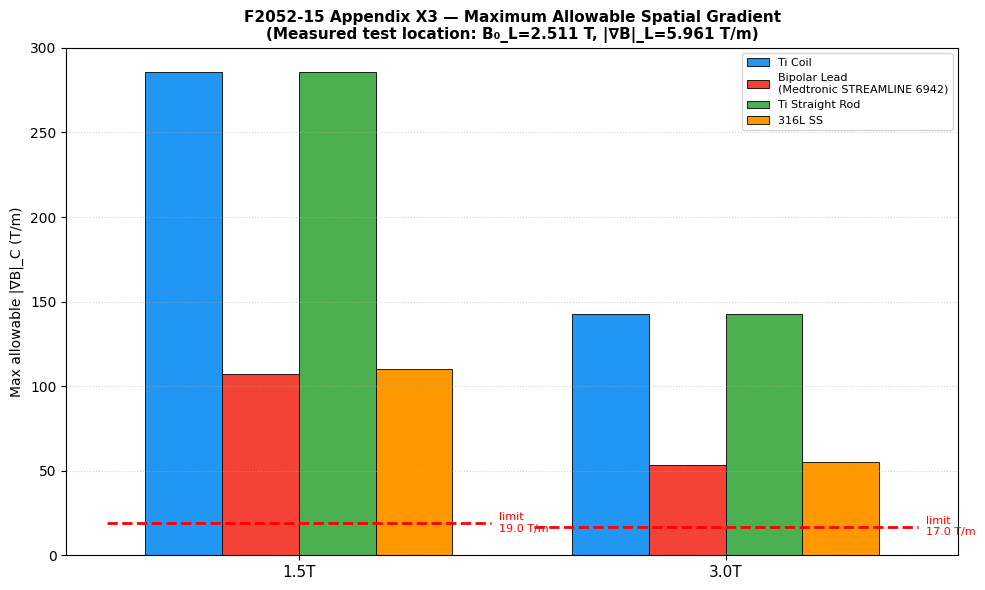

Saved: comparison_allowable_gradient.png


In [5]:
# ── Plot A: Allowable |∇B|_C per device per scanner ──────────────
DEVICE_COLORS = {
    'Ti_Coil':      '#2196F3',
    'Bipolar_Lead': '#F44336',
    'Ti_Rod':       '#4CAF50',
    'SS_316L':      '#FF9800',
}
DEVICE_LABELS = {
    'Ti_Coil':      'Ti Coil',
    'Bipolar_Lead': 'Bipolar Lead\n(Medtronic STREAMLINE 6942)',
    'Ti_Rod':       'Ti Straight Rod',
    'SS_316L':      '316L SS',
}

scanners   = list(CLINICAL_B0.keys())
devices    = list(mean_results.keys())
x          = np.arange(len(scanners))
bar_width  = 0.18
offsets    = np.linspace(-(len(devices)-1)/2, (len(devices)-1)/2, len(devices)) * bar_width

fig, ax = plt.subplots(figsize=(10, 6))

for offset, device in zip(offsets, devices):
    vals = [
        extrap_df[
            (extrap_df['Device'] == device) &
            (extrap_df['Scanner'] == sc)
        ]['Max |∇B|_C (T/m)'].values[0]
        for sc in scanners
    ]
    ax.bar(x + offset, vals,
           width=bar_width,
           color=DEVICE_COLORS[device],
           edgecolor='black', linewidth=0.6,
           label=DEVICE_LABELS[device])

# Scanner limit lines
for i, sc in enumerate(scanners):
    lim = SCANNER_GRAD_LIMITS[sc]
    ax.hlines(lim, i - 0.45, i + 0.45,
              colors='red', linewidths=2, linestyles='--')
    ax.text(i + 0.47, lim, f'limit\n{lim} T/m',
            va='center', color='red', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(scanners, fontsize=11)
ax.set_ylabel('Max allowable |∇B|_C (T/m)', fontsize=10)
ax.set_title('F2052-15 Appendix X3 — Maximum Allowable Spatial Gradient\n'
             f'(Measured test location: B₀_L={B0_L:.3f} T, |∇B|_L={gradB_L:.3f} T/m)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.set_ylim(0)
plt.tight_layout()
plt.savefig('comparison_allowable_gradient.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_allowable_gradient.png')

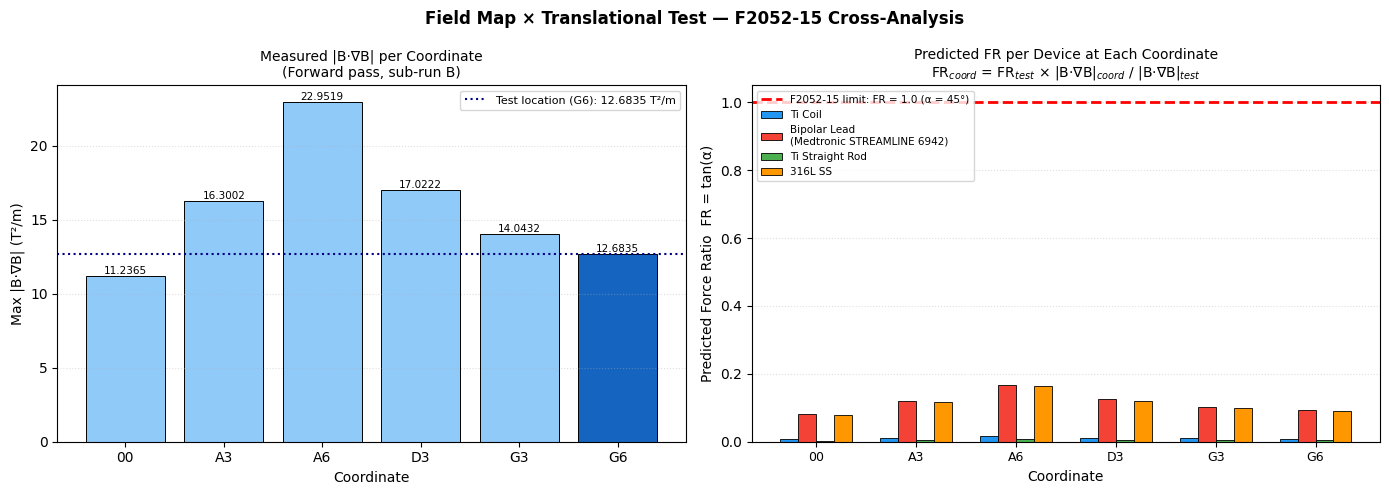

Saved: comparison_FR_per_coordinate.png


In [6]:
# ── Plot B: Measured |B·∇B| per coordinate vs device FR threshold ─
# For each device, the threshold |B·∇B| that would produce FR=1 is:
#   |B·∇B|_threshold = tan(α_measured) × μ₀g × ρ/χ
# but since we don't know χ/ρ independently, we instead plot:
#   The measured |B·∇B| at each coordinate, and overlay what FR each
#   device would experience there, computed as:
#   FR_predicted = tan(α_L) × (|B·∇B|_coord / |B·∇B|_L)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: |B·∇B| per coordinate (field map) ──────────────────────
ax = axes[0]
coords     = field_summary['coord'].tolist()
BgradB_vals = field_summary['mean_BgradB'].tolist()
bar_colors = ['#90CAF9' if c != TEST_COORD else '#1565C0' for c in coords]

bars = ax.bar(coords, BgradB_vals, color=bar_colors,
              edgecolor='black', linewidth=0.7)
ax.axhline(BgradB_L, color='navy', linewidth=1.5, linestyle=':',
           label=f'Test location ({TEST_COORD}): {BgradB_L:.4f} T²/m')
ax.set_ylabel('Max |B·∇B| (T²/m)', fontsize=10)
ax.set_xlabel('Coordinate', fontsize=10)
ax.set_title('Measured |B·∇B| per Coordinate\n(Forward pass, sub-run B)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(axis='y', linestyle=':', alpha=0.4)
for bar, val in zip(bars, BgradB_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

# ── Right: predicted FR per device at each coordinate ────────────
ax = axes[1]
x       = np.arange(len(coords))
bar_w   = 0.18
offsets = np.linspace(-(len(devices)-1)/2, (len(devices)-1)/2, len(devices)) * bar_w

if BgradB_L > 0:
    for offset, device in zip(offsets, devices):
        tan_L = mean_results[device]['mean_tan_alpha'].max()
        # Scale FR linearly with |B·∇B| (valid for paramagnetic — X3.4)
        predicted_FR = [tan_L * (bg / BgradB_L) for bg in BgradB_vals]
        ax.bar(x + offset, predicted_FR,
               width=bar_w,
               color=DEVICE_COLORS[device],
               edgecolor='black', linewidth=0.6,
               label=DEVICE_LABELS[device])

ax.axhline(1.0, color='red', linewidth=2, linestyle='--',
           label='F2052-15 limit: FR = 1.0 (α = 45°)')
ax.set_xticks(x)
ax.set_xticklabels(coords, fontsize=9)
ax.set_ylabel('Predicted Force Ratio  FR = tan(α)', fontsize=10)
ax.set_xlabel('Coordinate', fontsize=10)
ax.set_title('Predicted FR per Device at Each Coordinate\n'
             r'FR$_{coord}$ = FR$_{test}$ × |B·∇B|$_{coord}$ / |B·∇B|$_{test}$',
             fontsize=10)
ax.legend(fontsize=7.5, loc='upper left')
ax.grid(axis='y', linestyle=':', alpha=0.4)
ax.set_ylim(0)

fig.suptitle('Field Map × Translational Test — F2052-15 Cross-Analysis',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison_FR_per_coordinate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: comparison_FR_per_coordinate.png')

## 6. Consolidated Report

In [7]:
print("══════════════════════════════════════════════════════════════════════")
print("  F2052-15 CROSS-ANALYSIS REPORT")
print("  Clinical Field Map × Translational Pendulum Test")
print("══════════════════════════════════════════════════════════════════════")
print(f"  Test coordinate      : {TEST_COORD} (bore axis representative)")
print(f"  Measured B₀_L        : {B0_L:.4f} T")
print(f"  Measured |∇B|_L      : {gradB_L:.4f} T/m")
print(f"  Measured |B·∇B|_L    : {BgradB_L:.5f} T²/m")
print(f"  §8.1 location check  : |∇B| = {pct_of_max:.1f}% of axis max "
      f"({'✅ PASS' if ok_location else '⚠ FAIL — reposition'})")
print()

print("  ── Per-device results ──────────────────────────────────────────")
for material, df in mean_results.items():
    max_tan   = df['mean_tan_alpha'].max()
    max_alpha = df['mean_alpha_deg'].max()
    n_t       = int(df['n_trials'].iloc[0])
    fr_pass   = max_tan < 1.0

    print(f"\n  {material}  ({n_t} trial{'s' if n_t>1 else ''})")
    print(f"    Translational test : max FR = {max_tan:.5f}  (α = {max_alpha:.3f}°)  "
          f"{'✅ FR < 1' if fr_pass else '❌ FR ≥ 1'}")
    print(f"    χ/ρ (implied)      : {chi_rho[material]:.4e} m³/kg")

    for scanner in scanners:
        row = extrap_df[
            (extrap_df['Device'] == material) &
            (extrap_df['Scanner'] == scanner)
        ].iloc[0]
        lim  = row['Scanner limit (T/m)']
        maxg = row['Max |∇B|_C (T/m)']
        ok   = row['Tolerance > Scanner max (PASS)']
        print(f"    {scanner} extrapolation : max |∇B|_C = {maxg:.3f} T/m  "
              f"(limit {lim} T/m)  {'✅' if ok else '⚠'}")

print()
print("  ── Notes ───────────────────────────────────────────────────────")
print("  • Ti Rod and SS_316L have N=1 trial — §8.2 requires ≥3.")
print("    Results should be treated as preliminary.")
print("  • This analysis covers displacement force only (§1.2).")
print("    Torque (F2213) and RF heating (F2182) must also be assessed.")
print("  • FR < 1 does not constitute MR safety clearance (§5.4).")
print("══════════════════════════════════════════════════════════════════════")

══════════════════════════════════════════════════════════════════════
  F2052-15 CROSS-ANALYSIS REPORT
  Clinical Field Map × Translational Pendulum Test
══════════════════════════════════════════════════════════════════════
  Test coordinate      : G6 (bore axis representative)
  Measured B₀_L        : 2.5114 T
  Measured |∇B|_L      : 5.9614 T/m
  Measured |B·∇B|_L    : 12.68349 T²/m
  §8.1 location check  : |∇B| = 100.0% of axis max (✅ PASS)

  ── Per-device results ──────────────────────────────────────────

  Ti_Coil  (3 trials)
    Translational test : max FR = 0.00924  (α = 0.529°)  ✅ FR < 1
    χ/ρ (implied)      : 7.6094e-09 m³/kg
    1.5T extrapolation : max |∇B|_C = 285.818 T/m  (limit 19.0 T/m)  ✅
    3.0T extrapolation : max |∇B|_C = 142.909 T/m  (limit 17.0 T/m)  ✅

  Bipolar_Lead  (3 trials)
    Translational test : max FR = 0.09314  (α = 5.321°)  ✅ FR < 1
    χ/ρ (implied)      : 7.6693e-08 m³/kg
    1.5T extrapolation : max |∇B|_C = 107.160 T/m  (limit 19.0 T/m)  ✅
  